<a href="https://colab.research.google.com/github/giraseniraj21-cyber/ML/blob/main/Practical_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

*   Student Name : Niraj jaypalsinig Girase
*   Div : A
*   Practical Batch : A2
*   Roll No. : 41
*   Date :
*   Practical No. : 01
*   Practical Name : Implement simple and multiple linear regression using Numpy and using Scikit RMSE and R2 values.

1] IMPORT LIBRARIES

In [7]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

2] DATA COLLECTION

In [8]:
# Create the dataset
data = {
    "Study_Hours": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    "Attendance": [60, 85, 70, 95, 65, 80, 90, 75, 88, 72],
    "Marks": [32, 42, 47, 58, 61, 67, 76, 79, 88, 91]
}

# Convert dict into DataFrame
df = pd.DataFrame(data)
print(df)

   Study_Hours  Attendance  Marks
0            1          60     32
1            2          85     42
2            3          70     47
3            4          95     58
4            5          65     61
5            6          80     67
6            7          90     76
7            8          75     79
8            9          88     88
9           10          72     91


3] EDA AND PREPROCESSING

In [9]:
print('First Five Rows:')
df.head()

First Five Rows:


,Study_Hours,Attendance,Marks
0,1,60,32
1,2,85,42
2,3,70,47
3,4,95,58
4,5,65,61


In [10]:
print('Shape of Dataset:')
df.shape

Shape of Dataset:


(10, 3)

In [11]:
print('Information:')
df.info()

Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Study_Hours  10 non-null     int64
 1   Attendance   10 non-null     int64
 2   Marks        10 non-null     int64
dtypes: int64(3)
memory usage: 372.0 bytes


In [12]:
print('Statistical Analysis:\n', df.describe())

Statistical Analysis:
        Study_Hours  Attendance      Marks
count     10.00000   10.000000  10.000000
mean       5.50000   78.000000  64.100000
std        3.02765   11.489125  19.790289
min        1.00000   60.000000  32.000000
25%        3.25000   70.500000  49.750000
50%        5.50000   77.500000  64.000000
75%        7.75000   87.250000  78.250000
max       10.00000   95.000000  91.000000


In [13]:
print('Check for null values:')
df.isnull().sum()

Check for null values:


,0
Study_Hours,0
Attendance,0
Marks,0


In [14]:
# Duplicate Values
df.duplicated().sum()

np.int64(0)

In [15]:
df.drop_duplicates()

,Study_Hours,Attendance,Marks
0,1,60,32
1,2,85,42
2,3,70,47
3,4,95,58
4,5,65,61
5,6,80,67
6,7,90,76
7,8,75,79
8,9,88,88
9,10,72,91


DATA VISUALIZATION

Text(0.5, 1.0, 'Correlation Heatmap')

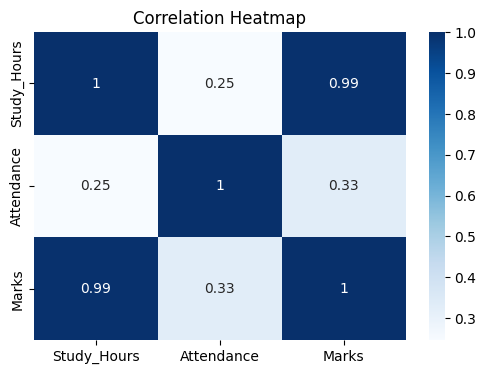

In [16]:
# Correlation Heatmap
import seaborn as sns

df_corr = df.corr()

plt.figure(figsize= (6, 4))
sns.heatmap(df_corr, annot=True, cmap='Blues')

plt.title('Correlation Heatmap')

A] SIMPLE LINEAR REGRESSION BY USING SCKIT-LEARN

In [17]:
# Feature Selection
x=df[['Study_Hours']]   #Independent Variable
y=df['Marks']           #Department Variable

4] MODEL BUILDING

In [18]:
#Split dataset into training and testing set
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

In [19]:
x_test

,Study_Hours
8,9
1,2
5,6


In [20]:
# Import Model
from sklearn.linear_model import LinearRegression
model = LinearRegression()

#Train the model
model.fit(x_train, y_train)

LinearRegression()

In [21]:
#Predict the valuees
y_pred=model.predict(x_test)
y_pred

array([86.55445545, 41.22772277, 67.12871287])

In [23]:
# Print Equation
print('Intercept:', model.intercept_)
print('Slope:', model.coef_[0])

Intercept: 28.277227722772274
Slope: 6.475247524752477


SLR EQUATION
*   Marks = (6.48*Study_Hours) + 28.27

In [25]:
# Evaluation
from sklearn.metrics import mean_squared_error, r2_score, mean_squared_error
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print('RSME:', round(rmse, 3))
print('R2 Score:', round(r2, 2))

RSME: 0.949
R2 Score: 1.0


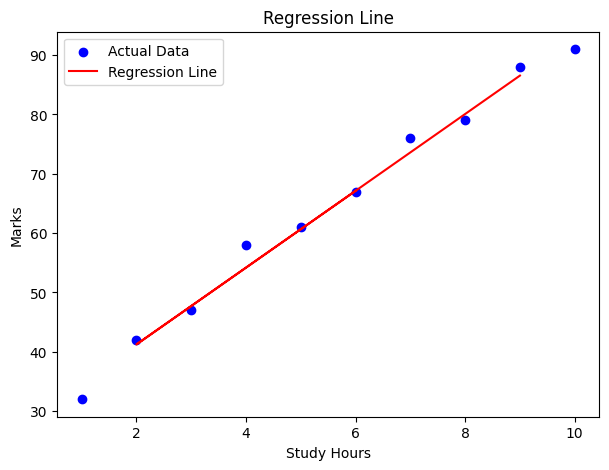

In [26]:
#Regression Line

plt.figure(figsize=(7, 5))
plt.scatter(x, y, color='blue', label='Actual Data')
plt.plot(x_test, y_pred,
         color='red',
         label='Regression Line')

plt.xlabel('Study Hours')
plt.ylabel('Marks')
plt.title('Regression Line')
plt.legend()
plt.show()

RESIDUAL PLOT

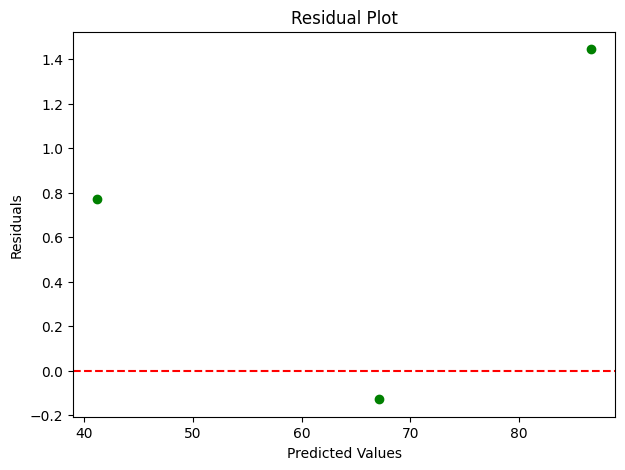

In [28]:
residuals = y_test - y_pred   # Calculate Residual

plt.figure(figsize=(7, 5))
plt.scatter (y_pred, residuals, color='green')
plt.axhline(y=0,
            color='red',
            linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

B] SIMPLE LINEAR RREGRESSION BY USING NUMPY

In [29]:
# Independent Variable (Fetures)
x = df["Study_Hours"].values

# Dependent Variable (Target)
y - df["Marks"].values

,Marks
0,0
1,0
2,0
3,0
4,0
5,0
6,0
7,0
8,0
9,0


In [30]:
# Calculate mean
x_mean = np.mean(x)
y_mean = np.mean(y)

In [31]:
# Calculate slope
m = np.sum((x - x_mean) * (y - y_mean)) / np.sum((x - x_mean) ** 2)

# Calculate intercept
b = y_mean - m * x_mean

print("Slope =", m)
print("Intercept =", b)

Slope = 6.503030303030303
Intercept = 28.33333333333333


In [32]:
# Prediction
y_pred_numpy = m*x + b
y_pred_numpy

array([34.83636364, 41.33939394, 47.84242424, 54.34545455, 60.84848485,
       67.35151515, 73.85454545, 80.35757576, 86.86060606, 93.36363636])

MULTIPLE LINEAR REGRESSION

In [33]:
# Feature Selection
x = df[['Study_Hours', 'Attendance']]   # Independent Variables
y = df['Marks']                          # Dependent Variable

# Split Dataset
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

MODEL BUILDING

In [34]:
model=LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

In [35]:
# Prediction
y_pred =model.predict(x_test)
y_pred

array([88.08653885, 43.59718321, 67.84336712])

In [36]:
# Model Parameters
print('Intercept:', model.intercept_)
print("Coefficients",)
coeff=pd.DataFrame({
    'Feaure': x.columns,
    'Coefficient': model.coef_
})

print(coeff)

Intercept: 16.14458419831481
Coefficients
        Feaure  Coefficient
0  Study_Hours     6.280539
1   Attendance     0.175194


MLR EQUATION
*   Marks = (6.29Study_Hours) + (0.18 Attendance) + 16.15

MODEL EVALUTION

In [38]:
# Evaluate Metrics
print('Metrics Values of MLR:')
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print('RSME:', round(rmse, 2))
print('R2 Score:', round(r2, 2))

Metrics Values of MLR:
RSME: 1.04
R2 Score: 1.0


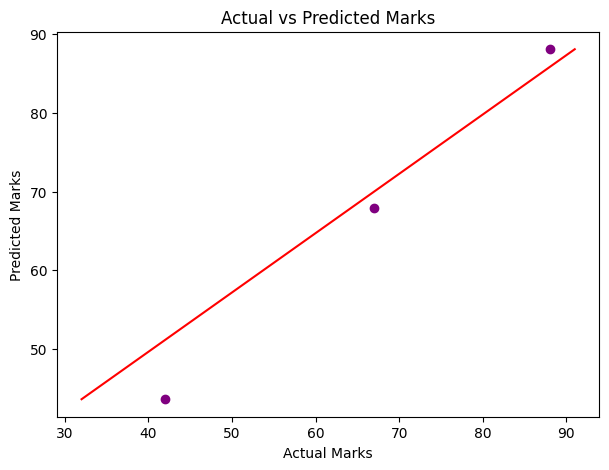

In [41]:
# Actual vs Predicted Plot
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred, color='Purple')

# perfectr Prediction Line
plt.plot([y.min(), y.max()],
          [y_pred.min(), y_pred.max()],
           color='red')

plt.xlabel('Actual Marks')
plt.ylabel('Predicted Marks')
plt.title('Actual vs Predicted Marks')
plt.show()

RESIDUAL PLOT

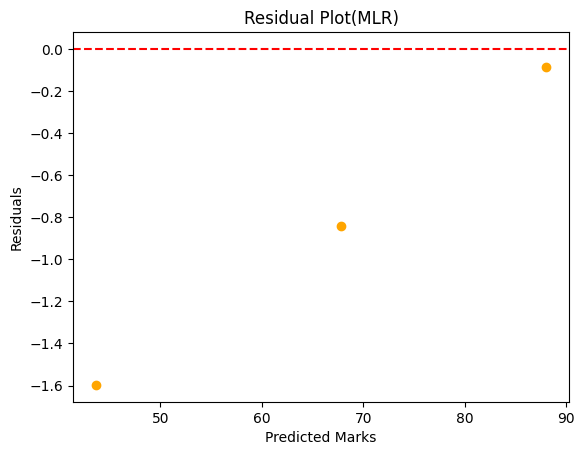

In [42]:
residuals = y_test - y_pred   #calculate residual

plt.scatter(y_pred, residuals, color='Orange')
plt.axhline(y=0, color='red',
            linestyle='--')
plt.xlabel('Predicted Marks')
plt.ylabel('Residuals')
plt.title('Residual Plot(MLR)')
plt.show()